# Beverage Sales - Product Performance Analysis

In [1]:
 # Importing dependecies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [6]:
# Setup pandas to import the dataset
folder_path = 'B:/Bootcamp/Final Project Data Analysis'
path = folder_path + '/clean_beverage_sales.csv'
df = pd.read_csv(path)
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Year,Month,Day_of_Week
0,ORD1663596,CUS5073,B2B,Hohes C Orange,Juices,1.87,74,0.10,124.54,Niedersachsen,2023-11-29,2023,November,Wednesday
1,ORD1999010,CUS141,B2B,Fritz-Kola,Soft Drinks,1.87,18,0.05,31.98,Bremen,2021-05-13,2021,May,Thursday
2,ORD347756,CUS562,B2B,Merlot,Alcoholic Beverages,12.04,71,0.15,726.61,Thüringen,2021-04-21,2021,April,Wednesday
3,ORD600360,CUS7718,B2B,Moët & Chandon,Alcoholic Beverages,64.91,91,0.10,5316.13,Hamburg,2021-08-23,2021,August,Monday
4,ORD2300591,CUS6160,B2C,Granini Apple,Juices,1.64,4,0.00,6.56,Sachsen,2022-10-16,2022,October,Sunday


In [7]:
# Breakdown the columns
num_col = ['Quantity', 'Unit_Price', 'Discount', 'Total_Price']
df[num_col].describe()

,Quantity,Unit_Price,Discount,Total_Price
count,9989.00,9989.00,9989.00,9989.00
mean,22.79,5.88,0.03,135.24
std,26.57,15.10,0.04,528.66
min,1.00,0.33,0.00,0.35
25%,6.00,1.05,0.00,8.30
50%,11.00,1.75,0.00,20.69
75%,29.00,3.19,0.05,67.97
max,100.00,138.72,0.15,10111.96


In [8]:
catg_col = ['Customer_Type', 'Product', 'Category', 'Region', 'Order_Date']
df[catg_col].describe()

,Customer_Type,Product,Category,Region,Order_Date
count,9989,9989,9989,9989,9989
unique,2,47,4,16,1094
top,B2C,Mango Juice,Water,Hamburg,2021-11-15
freq,6451,381,2549,710,23


# EDA

**Business Questions :**
1. Best selling beverage category in each region
2. Which product generates most revenue 
3. Does discount impactful to the qty sold
4. Which discount are most effective driving sales

In [43]:
# 1. Best selling beverage category in each region

beverage_category = pd.pivot_table(df, values='Quantity', index='Category', columns='Region', aggfunc='sum')
beverage_category = beverage_category.reset_index().melt(id_vars='Category', var_name='Region', value_name='Total')
beverage_category

,Category,Region,Total
0,Alcoholic Beverages,Baden-Württemberg,4162
1,Juices,Baden-Württemberg,3404
2,Soft Drinks,Baden-Württemberg,3693
3,Water,Baden-Württemberg,3228
4,Alcoholic Beverages,Bayern,3592
...,...,...,...
59,Water,Schleswig-Holstein,3483
60,Alcoholic Beverages,Thüringen,2976
61,Juices,Thüringen,2919
62,Soft Drinks,Thüringen,3366


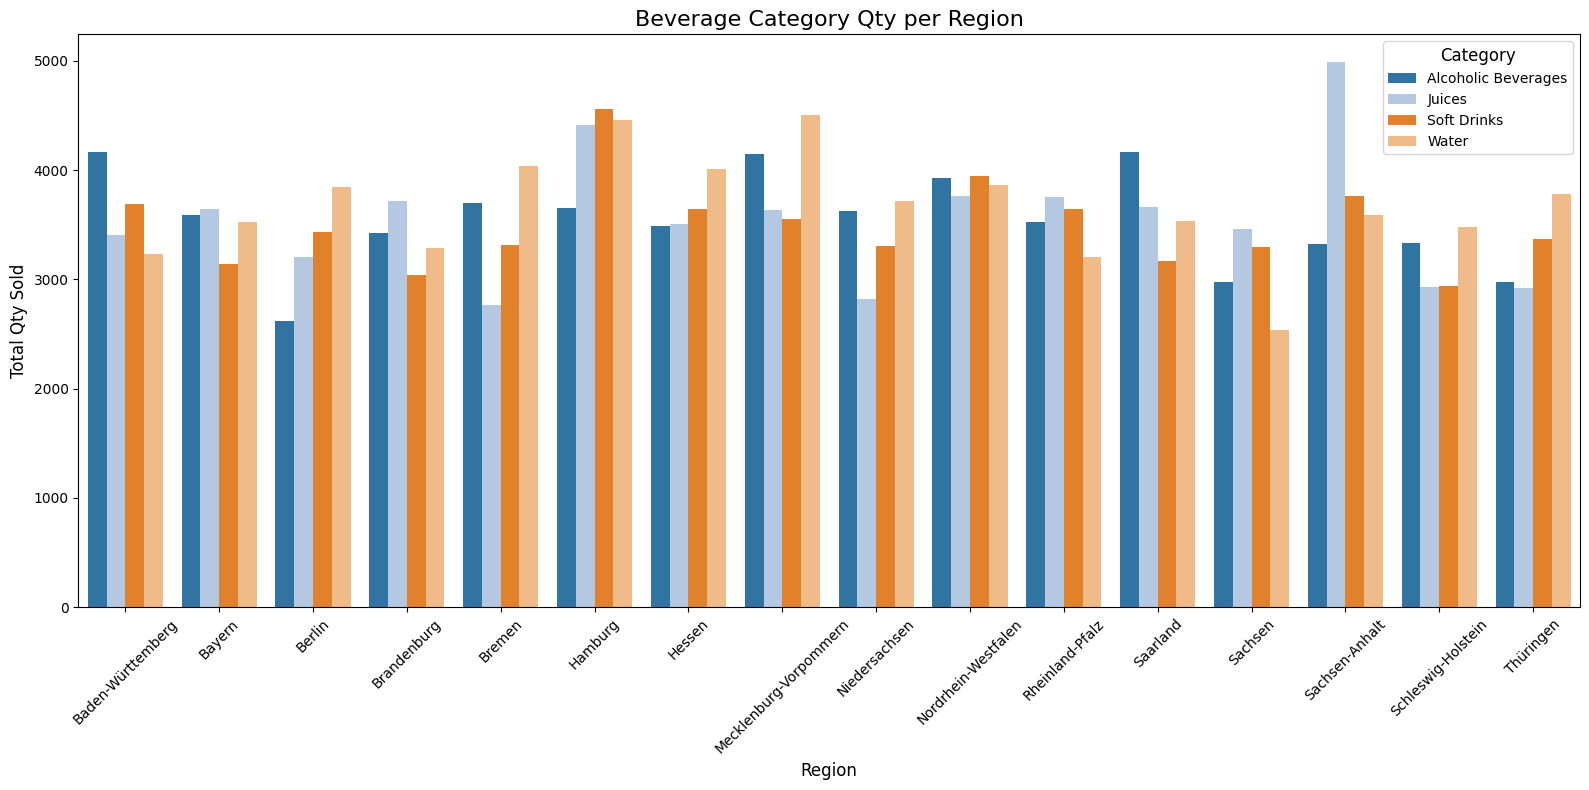

In [44]:
# Visualization
# Graph size
plt.figure(figsize=(16, 8))

# Barplot
sns.barplot(data=beverage_category, x='Region', y='Total', hue='Category', palette='tab20')

# Title and label
plt.title('Beverage Category Qty per Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Qty Sold', fontsize=12)
plt.xticks(rotation=45)

# Legend
plt.legend(title='Category', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

Observations:
1. Alcoholic Beverages are strong in Baden-Wurttemberg, Saarland, and Mecklenburg-Vorpommern and weak in Berlin, Sachsen, and Thuringen.
2. Soft drinks have a pretty balanced performance but exceptionally in Hamburg
3. Juices in Sachsen-Anhalt is the top quantity sold above any other region and any other category

## Extra analysis on alcoholic beverages impact to other category

In [47]:
beverages_catg = pd.pivot_table(df, values='Quantity', index='Region', columns='Category', aggfunc='sum')
beverages_catg = beverages_catg.reset_index()
beverages_catg

Category,Region,Alcoholic Beverages,Juices,Soft Drinks,Water
0,Baden-Württemberg,4162,3404,3693,3228
1,Bayern,3592,3647,3142,3524
2,Berlin,2623,3202,3435,3844
3,Brandenburg,3428,3715,3040,3283
4,Bremen,3700,2765,3317,4038
5,Hamburg,3651,4413,4560,4462
6,Hessen,3486,3504,3644,4010
7,Mecklenburg-Vorpommern,4148,3631,3554,4506
8,Niedersachsen,3621,2819,3301,3718
9,Nordrhein-Westfalen,3927,3766,3944,3860


<Axes: xlabel='Category', ylabel='Category'>

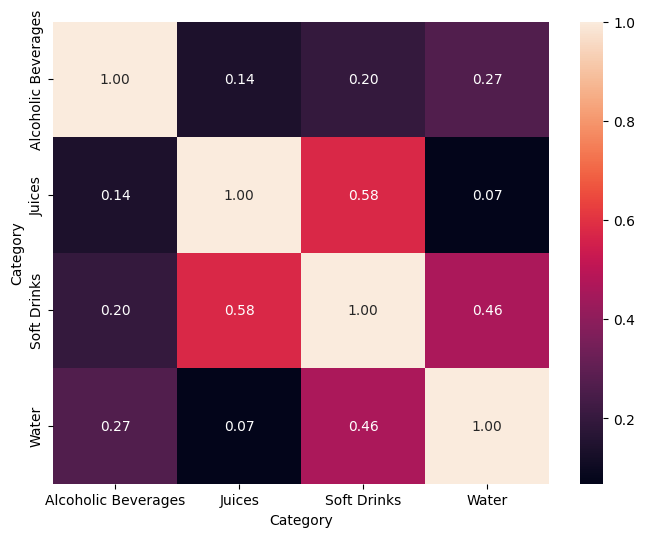

In [48]:
categories = ['Alcoholic Beverages', 'Juices', 'Soft Drinks', 'Water']
plt.figure(figsize=(8,6))
correlation = beverages_catg[categories].corr()
sns.heatmap(correlation, annot=True, fmt='.2f')

In [85]:
# 2. Which product generates most revenue

products_revenue = df.groupby('Product')['Total_Price'].sum()
products_revenue = products_revenue.reset_index().sort_values(by= 'Total_Price', ascending=False)
top_products_revenue = products_revenue.head(10)
top_products_revenue

,Product,Total_Price
26,Moët & Chandon,234408.98
41,Veuve Clicquot,217797.67
18,Johnnie Walker,129695.40
16,Jack Daniels,110920.27
39,Tanqueray,89748.31
2,Bacardi,74350.04
14,Havana Club,58484.73
35,Sauvignon Blanc,26231.43
4,Chardonnay,26044.13
7,Cranberry Juice,26020.86


C:\Users\Arie\AppData\Local\Temp\ipykernel_7040\2906092245.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products_revenue, x='Total_Price', y='Product', palette='tab20')


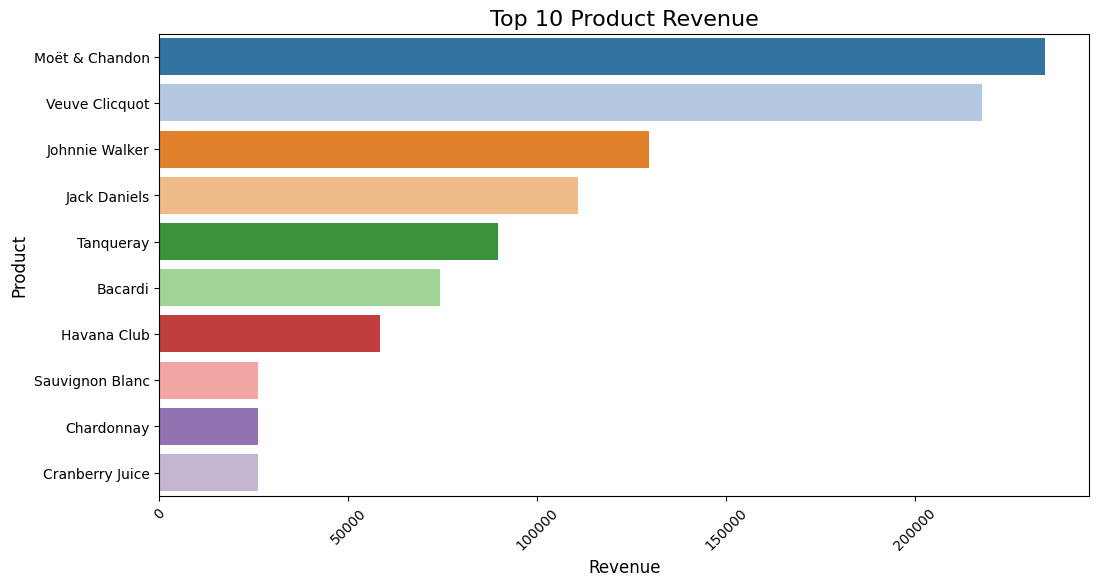

In [99]:
# Graph size
plt.figure(figsize=(12,6))

# Barplot
sns.barplot(data=top_products_revenue, x='Total_Price', y='Product', palette='tab20')

# Title and Label
plt.title('Top 10 Product Revenue', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.xticks(rotation=45)

plt.show()

Observations:
1. Top 9 of products are alcoholic beverages
2. Moet & Chandon generates 234408.98 in revenue

In [89]:
bottom_products_revenue = products_revenue.tail(10)
bottom_products_revenue = bottom_products_revenue.sort_values(by= 'Total_Price', ascending=True)
bottom_products_revenue

,Product,Total_Price
20,Kölsch,3192.84
23,Mezzo Mix,3611.08
44,Volvic,3810.88
10,Fanta,4232.37
17,Jever,4270.91
46,Warsteiner,4401.59
36,Schwip Schwap,4448.64
43,Vittel,4511.45
1,Augustiner,4572.94
25,Mountain Dew,4617.28


C:\Users\Arie\AppData\Local\Temp\ipykernel_7040\738449143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_products_revenue, x='Total_Price', y='Product', palette='tab20')


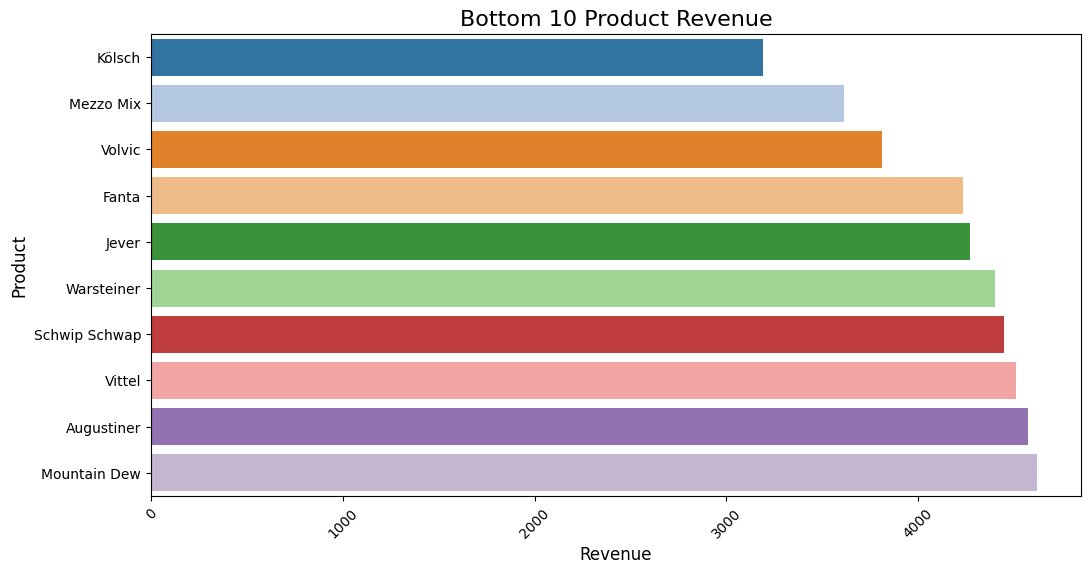

In [100]:
# Graph size
plt.figure(figsize=(12,6))

# Barplot
sns.barplot(data=bottom_products_revenue, x='Total_Price', y='Product', palette='tab20')

# Title and Label
plt.title('Bottom 10 Product Revenue', fontsize=16)
plt.xlabel('Revenue', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.xticks(rotation=45)

plt.show()

<Axes: >

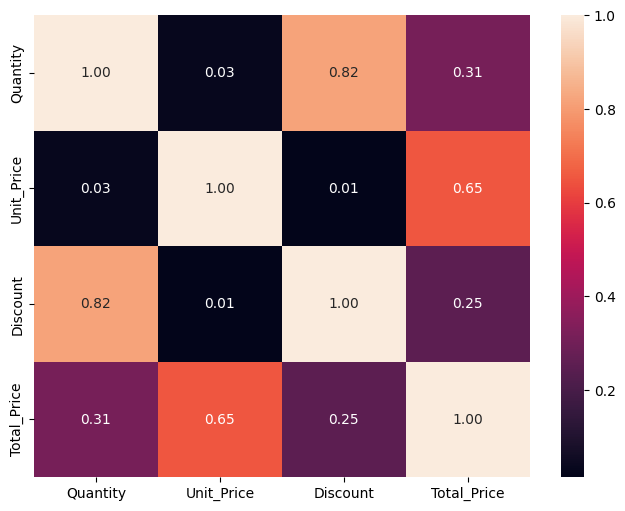

In [69]:
# 3. Does discount impactful to the qty sold and total_price

plt.figure(figsize=(8,6))
correlation = df[num_col].corr()
sns.heatmap(correlation, annot=True, fmt='.2f')

Observations:
1. Quantity and Discount correlation is 0.82 which indicates strong correlation and linear
2. Discount and Total_Price correlation is 0.25 indicates weak correlation and linear

To analyze further we can use ANOVA analysis to find difference in variance from discounts to normal

In [134]:
qty_discount = pd.pivot_table(df, values='Quantity', index='Product', columns='Discount', aggfunc='sum')
qty_discount = qty_discount.dropna().reset_index()
qty_discount

#discount0 = qty_discount[0.00].values
#discount1 = qty_discount[0.05].values
#discount2 = qty_discount[0.10].values
#discount3 = qty_discount[0.15].values
#discount3 = discount3[~np.isnan(discount3)]

Discount,Product,0.00,0.05,0.10,0.15
0,Apollinaris,1483.00,1571.00,2112.00,616.00
1,Augustiner,742.00,531.00,1066.00,319.00
2,Bacardi,710.00,573.00,1358.00,698.00
3,Beck's,950.00,901.00,1264.00,284.00
4,Chardonnay,869.00,746.00,1381.00,194.00
5,Club Mate,893.00,910.00,2165.00,366.00
6,Coca-Cola,1000.00,1362.00,1584.00,625.00
7,Cranberry Juice,1766.00,2395.00,3141.00,1004.00
8,Evian,1438.00,2105.00,2775.00,747.00
9,Fanta,1018.00,699.00,1760.00,592.00


In [150]:
from scipy.stats import f_oneway

# ANOVA
f_stat, p_value = f_oneway(discount0, discount1, discount2, discount3)
print(f"F-Statistic: {f_stat}, P-Value: {p_value}")

# Keputusan
alpha = 0.05
if p_value <= alpha:
    print("Reject H0, there are significant differences")
else:
    print("H0 Accepted, there are no significant differences")

F-Statistic: 39.93600010076588, P-Value: 6.677340816943314e-20
Reject H0, there are significant differences


Which discount gives the best trade-off between high quantity and high revenue?

In [98]:
# 4. Which discount gives the best trade-off between high quantity and high revenue
discount_analysis = df.groupby('Discount').agg({
    'Quantity': 'sum',
    'Total_Price': 'sum',
    'Order_ID': 'nunique'
}).reset_index()

discount_analysis['Avg_Quantity_per_Order'] = discount_analysis['Quantity'] / discount_analysis['Order_ID']
discount_analysis

,Discount,Quantity,Total_Price,Order_ID,Avg_Quantity_per_Order
0,0.00,51568,306184.49,6446,8.00
1,0.05,54604,297584.24,1615,33.81
2,0.10,90854,551838.69,1494,60.81
3,0.15,30594,195266.22,429,71.31


C:\Users\Arie\AppData\Local\Temp\ipykernel_7040\1446014068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Discount', y='Quantity', data=discount_analysis, palette='tab20')


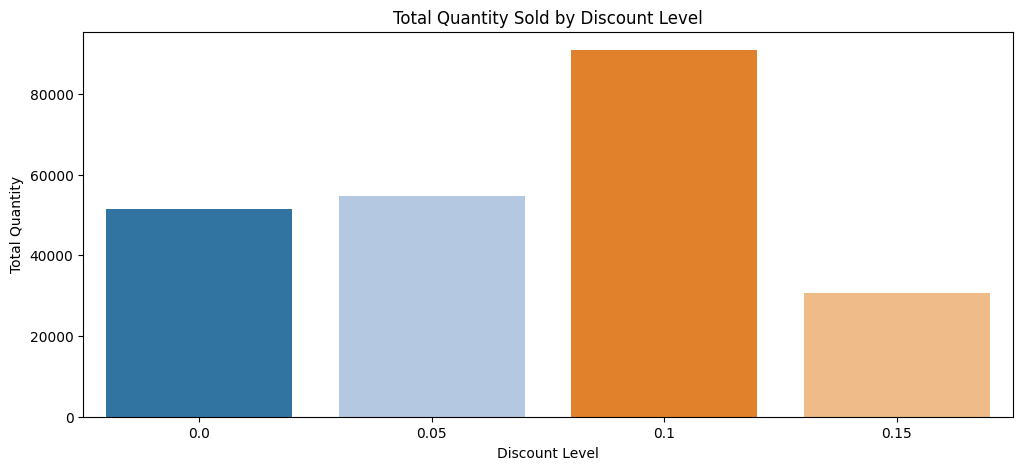

C:\Users\Arie\AppData\Local\Temp\ipykernel_7040\1446014068.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Discount', y='Total_Price', data=discount_analysis, palette='tab20')


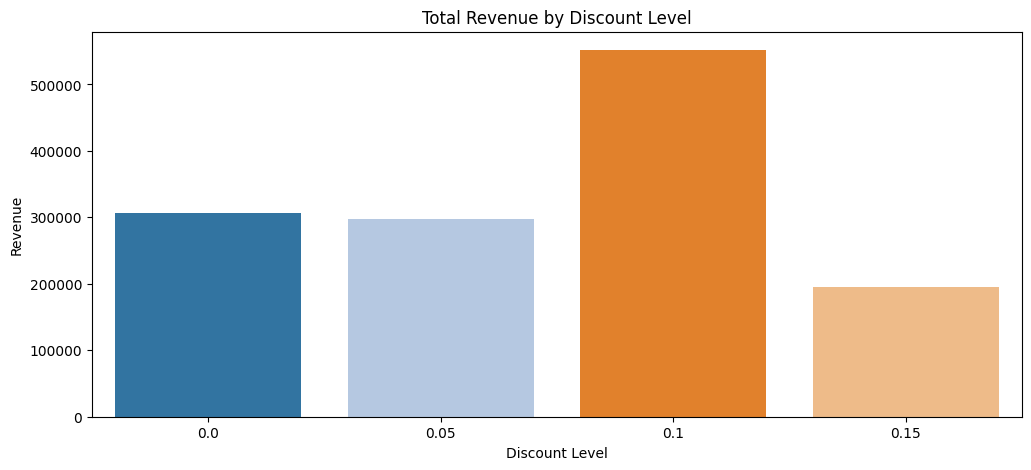

In [102]:
# Visualization
plt.figure(figsize=(12,5))
sns.barplot(x='Discount', y='Quantity', data=discount_analysis, palette='tab20')
plt.title('Total Quantity Sold by Discount Level')
plt.ylabel('Total Quantity')
plt.xlabel('Discount Level')
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(x='Discount', y='Total_Price', data=discount_analysis, palette='tab20')
plt.title('Total Revenue by Discount Level')
plt.ylabel('Revenue')
plt.xlabel('Discount Level')
plt.show()
